In [65]:
import sys
if '/disks/cosmodm/vdvuurst' not in sys.path:
    sys.path.append('/disks/cosmodm/vdvuurst')

import numpy as np
import h5py
from matplotlib import pyplot as plt
import os
from importlib import reload
import json
import ONEHALO
from tqdm import tqdm
from functions import modified_logspace, BIC
from onehalo_plotter import *
from functional_forms import *
format_plot()

from scipy.optimize import minimize


joint_test = ONEHALO.ONEHALO_joint_fitter()


### Testing initial conditions

In [66]:
init_path = '/disks/cosmodm/vdvuurst/data/onehalo_joint_initial_conditions'
joint_fitter = ONEHALO.ONEHALO_joint_fitter()

for i, file in enumerate(os.listdir(init_path)):
    fp = os.path.join(init_path, file)

    params, MCMC_stepsizes = np.load(fp)
    combi_nr = int(file.split('_')[-1].strip('.npy'))
    print(combi_nr)
    function_combi = all_combis[combi_nr - 1]
    function_combi_names = all_names[combi_nr - 1]
    n_params_r, n_params_m, ntot = ONEHALO.param_info(function_combi)

    split_params = joint_fitter.split_parameters(params, n_params_m)
    DG_params = joint_fitter.get_double_gauss_parameters(split_params, function_combi, n_params_r)

    print(DG_params)
    print()
    if i == 5:
        break

1047
[[150. 150. 150. ... 150. 150. 150.]
 [ 50.  50.  50. ...  50.  50.  50.]
 [  0.   0.   0. ...   0.   0.   0.]]

2346
[[150. 150. 150. ... 150. 150. 150.]
 [ 50.  50.  50. ...  50.  50.  50.]
 [  0.   0.   0. ...   0.   0.   0.]]

5572
[[150. 150. 150. ... 150. 150. 150.]
 [ 50.  50.  50. ...  50.  50.  50.]
 [  0.   0.   0. ...   0.   0.   0.]]

3622
[[150. 150. 150. ... 150. 150. 150.]
 [ 50.  50.  50. ...  50.  50.  50.]
 [  0.   0.   0. ...   0.   0.   0.]]

5394
[[150. 150. 150. ... 150. 150. 150.]
 [ 50.  50.  50. ...  50.  50.  50.]
 [  0.   0.   0. ...   0.   0.   0.]]

6030
[[150. 150. 150. ... 150. 150. 150.]
 [ 50.  50.  50. ...  50.  50.  50.]
 [  0.   0.   0. ...   0.   0.   0.]]



### Loading in data and setting up for MCMC tests

In [67]:
with h5py.File('/disks/cosmodm/vdvuurst/data/Onehalo_M_12-15.5_subsampled.hdf5') as handle:
    rel_vels = handle['rel_vels'][:]
    halo_masses = handle['mass'][:]
    rel_dist = handle['rel_dist'][:]

Best BIC: 4427 493479.1379491558


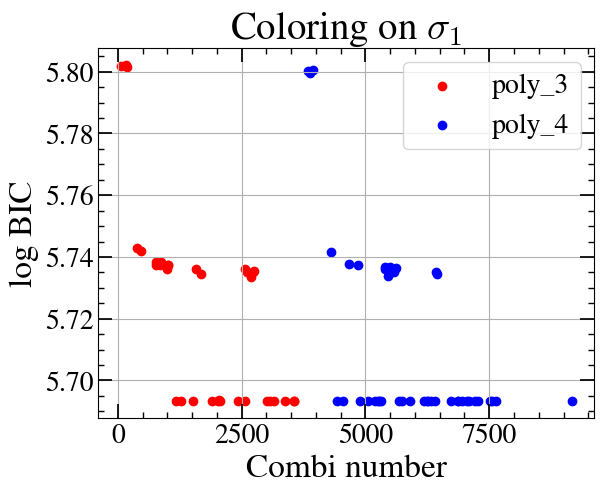

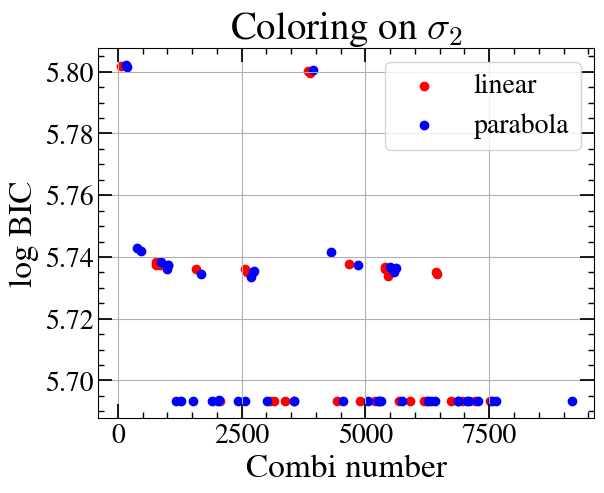

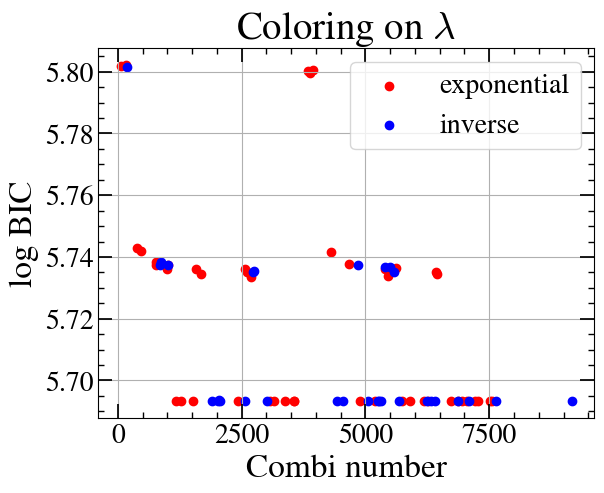

In [68]:
bics = np.empty(shape = len(os.listdir('/disks/cosmodm/vdvuurst/data/OneHalo_param_fits/joint_subsample')))

colors = ['red', 'blue', 'forestgreen', 'magenta', 'purple', 'black']
labels = ['poly_4_sigma_1', 'poly_3_sigma_1', 'linear_sigma_2', 'parabola_sigma_2', 'exp_lambda', 'inv_lambda']


combi_nrs = np.zeros_like(bics, dtype = int)
s1_colors = []
s2_colors = []
lam_colors = []
labels = []

for i,file in enumerate(os.listdir('/disks/cosmodm/vdvuurst/data/OneHalo_param_fits/joint_subsample')):
    filepath = os.path.join('/disks/cosmodm/vdvuurst/data/OneHalo_param_fits/joint_subsample', file)
    with open(filepath) as f:
        param_dict = json.load(f)
    bics[i] = param_dict['BIC']
    combi_nr = int(file.split('_')[-1].strip('.json'))
    combi_nrs[i] = combi_nr

    func_names = param_dict['functional_form']
    s1, s2, l = func_names

    match s1[0]:
        case 'poly_3':
            s1_colors.append('red')
        case 'poly_4':
            s1_colors.append('blue')
    
    match s2[0]:
        case 'linear':
            s2_colors.append('red')
        case 'parabola':
            s2_colors.append('blue')
    
    match l[0]:
        case 'exponential':
            lam_colors.append('red')
        case 'inverse':
            lam_colors.append('blue')
    
bestarg = np.nanargmin(bics)
best_combi_nrs = combi_nrs[np.argsort(bics)]
print('Best BIC:', combi_nrs[bestarg], bics[bestarg])

# coloring on sigma_1
cmask = np.array(s1_colors) == 'red'
plt.figure()
plt.scatter(combi_nrs[cmask], np.log10(bics[cmask]), c = 'red', label = 'poly_3')
plt.scatter(combi_nrs[np.invert(cmask)], np.log10(bics[np.invert(cmask)]), c = 'blue', label = 'poly_4')
ax = plt.gca()
ax.set_title(r'Coloring on $\sigma_1$')
ax.set(ylabel ='log BIC', xlabel = 'Combi number')
ax.grid()
ax.legend()
plt.show()
    
# coloring on sigma 2
cmask = np.array(s2_colors) == 'red'
plt.figure()
plt.scatter(combi_nrs[cmask], np.log10(bics[cmask]), c = 'red', label = 'linear')
plt.scatter(combi_nrs[np.invert(cmask)], np.log10(bics[np.invert(cmask)]), c = 'blue', label = 'parabola')
ax = plt.gca()
ax.set_title(r'Coloring on $\sigma_2$')
ax.set(ylabel ='log BIC', xlabel = 'Combi number')
ax.grid()
ax.legend()
plt.show()
    
#coloring on lambda
cmask = np.array(lam_colors) == 'red'

plt.figure()
plt.scatter(combi_nrs[cmask], np.log10(bics[cmask]), c = 'red', label = 'exponential')
plt.scatter(combi_nrs[np.invert(cmask)], np.log10(bics[np.invert(cmask)]), c = 'blue', label = 'inverse')
ax = plt.gca()
ax.set_title(r'Coloring on $\lambda$')
ax.set(ylabel ='log BIC', xlabel = 'Combi number')
ax.grid()
ax.legend()
plt.show()
    



In [69]:
def get_DG_from_combi_nr(combi_nr):
    func_combi = all_combis[combi_nr - 1]
    n_params_r, n_params_m, ntot = ONEHALO.param_info(func_combi)

    with open(f'/disks/cosmodm/vdvuurst/data/OneHalo_param_fits/joint_subsample/function_combi_{combi_nr}.json') as f:
        param_dict = json.load(f)
    
    params = np.array(param_dict['parameters'])
    split_params = joint_test.split_parameters(params, n_params_m)
    DG = joint_test.get_double_gauss_parameters(split_params, func_combi, n_params_r)

    return DG

for combi_nr in best_combi_nrs: # sorted from lowest BIC to highest
    DG_i = get_DG_from_combi_nr(combi_nr)
    print(combi_nr, DG_i[2].nonzero())



4427 (array([], dtype=int64),)
6236 (array([], dtype=int64),)
5259 (array([], dtype=int64),)
5277 (array([], dtype=int64),)
4556 (array([], dtype=int64),)
6397 (array([], dtype=int64),)
2434 (array([], dtype=int64),)
5312 (array([], dtype=int64),)
6332 (array([], dtype=int64),)
6185 (array([], dtype=int64),)
7514 (array([], dtype=int64),)
7556 (array([], dtype=int64),)
2559 (array([], dtype=int64),)
6266 (array([], dtype=int64),)
7630 (array([], dtype=int64),)
5192 (array([], dtype=int64),)
5893 (array([], dtype=int64),)
2063 (array([], dtype=int64),)
9168 (array([], dtype=int64),)
1529 (array([], dtype=int64),)
7209 (array([], dtype=int64),)
6864 (array([], dtype=int64),)
3074 (array([], dtype=int64),)
7100 (array([], dtype=int64),)
7271 (array([], dtype=int64),)
1185 (array([], dtype=int64),)
3557 (array([], dtype=int64),)
3386 (array([], dtype=int64),)
5676 (array([], dtype=int64),)
3562 (array([], dtype=int64),)
5052 (array([], dtype=int64),)
1268 (array([], dtype=int64),)
7042 (ar

In [70]:
reload(ONEHALO)
from ONEHALO_initial_conditions import _init_conditions

from warnings import filterwarnings
# this might be a liiiitle dangerous but cleans up the output by a lot. that's because we often see invalid values in log10, but that's ok
filterwarnings('ignore',category = RuntimeWarning)

combi_nr = 6421 # not an index
test_func_combi = all_combis[combi_nr - 1]
test_func_combi_names = all_names[combi_nr - 1]

init_guess, MCMC_scales = np.load(f'/disks/cosmodm/vdvuurst/data/onehalo_joint_initial_conditions/function_combi_{combi_nr}.npy')
MCMC_scales = MCMC_scales[:, np.newaxis]
simple = _init_conditions(test_func_combi_names)

print(ONEHALO.param_info(test_func_combi))

nwalkers = 35
nsteps = 500
n_params_r, n_params_m, ntot = ONEHALO.param_info(test_func_combi)

# joint_test.fit_function_combi_to_data(test_func_combi, test_func_combi_names, combi_nr, nwalkers,
#                                       nsteps, verbose = True, plot = True)

with open(f'/disks/cosmodm/vdvuurst/data/OneHalo_param_fits/joint_subsample/function_combi_{combi_nr}.json') as f:
    param_dict = json.load(f)

params = np.array(param_dict['parameters'])

split_params = joint_test.split_parameters(params, n_params_m)
DG = joint_test.get_double_gauss_parameters(split_params, test_func_combi, n_params_r)
DG

([5, 2, 3], [2, 3, 3, 3, 3, 2, 3, 2, 3, 3], 27)


array([[246.63438416, 183.93029785, 181.94819641, ..., 321.68960571,
        207.82640076, 260.87643433],
       [ 56.44850922,  52.64242554,  52.34866714, ...,  57.51883698,
         54.16021347,  57.26404953],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ]], shape=(3, 34447))

In [71]:
param_dict

{'parameters': [0.8366739963478966,
  0.20766814392393151,
  0.9041911985009037,
  0.22774557354155403,
  -0.018017155061554248,
  0.7764095700626407,
  0.6216625031656939,
  -0.10547730282255567,
  1.3856836432494022,
  0.4153560241291905,
  0.05023282628447683,
  3.6331248639329203,
  1.1582073394437855,
  150.15113301566072,
  0.6409317199873106,
  -0.04214562180278918,
  0.22444952295835216,
  0.21829964231199242,
  49.85800395007076,
  -1.9014439391590627,
  -0.553316288033909,
  0.18610140157203303,
  -0.2166389540294269,
  -0.15839993874388375,
  0.07654933916022083,
  0.023545248251816028,
  -0.007954168542687023],
 'likelihood': 271583.5058388815,
 'BIC': 543449.0854618908,
 'functional_form': [['poly_4',
   ['linear', 'parabola', 'parabola', 'parabola', 'parabola']],
  ['linear', ['linear', 'parabola']],
  ['exponential', ['linear', 'parabola', 'exponential']]],
 'nwalkers': 41,
 'nsteps': 1000}

### Important diagnostics on the results

In [72]:
# sigma1 and sigma2 move only *very* slightly while lambda, on average, goes outside of prior range
print(DG[0].mean(), np.std(DG[0]))
print(DG[1].mean(), np.std(DG[1]))
print(DG[2].mean(), np.std(DG[2]))
print()

prior_mask = log_prior_vec(DG) == 0
print(f'{prior_mask.sum()} points pass the prior')
try: 
    print(halo_masses[np.invert(prior_mask)].min(), halo_masses[np.invert(prior_mask)].max()) # sometimes, only part of mass space gets through the prior
    print(rel_dist[np.invert(prior_mask)].min(), rel_dist[np.invert(prior_mask)].max()) # all of radial space gets through
except:
    pass

# Note how, within prior range, the only significant change is in the lambda parameter. what does this mean?
print()
print(DG[0, prior_mask].mean(), np.std(DG[0, prior_mask]))
print(DG[1, prior_mask].mean(), np.std(DG[1, prior_mask]))
print(DG[2, prior_mask].mean(), np.std(DG[2, prior_mask]))


226.7191393961286 56.83307793033451
54.59840860371528 1.9706690378091034
0.0001174297280738355 0.0021036385584962364

34447 points pass the prior

226.7191393961286 56.83307793033451
54.59840860371528 1.9706690378091034
0.0001174297280738355 0.0021036385584962364


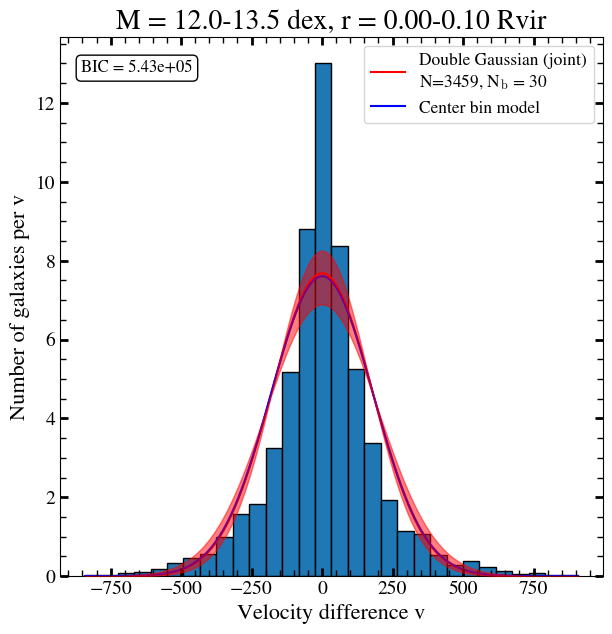

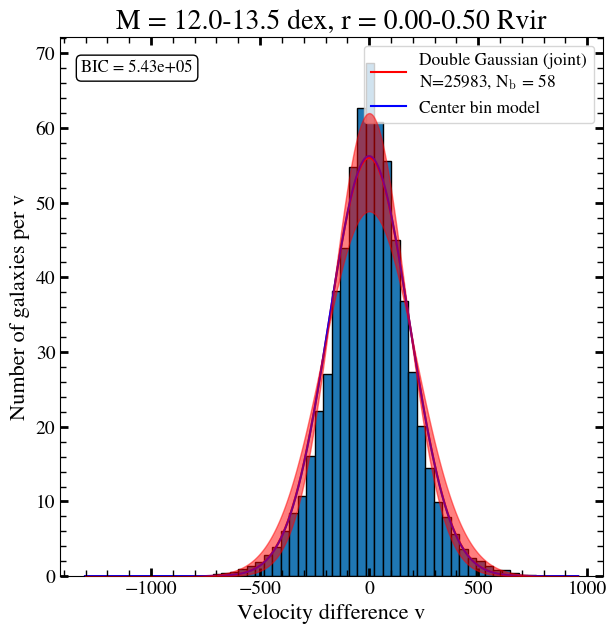

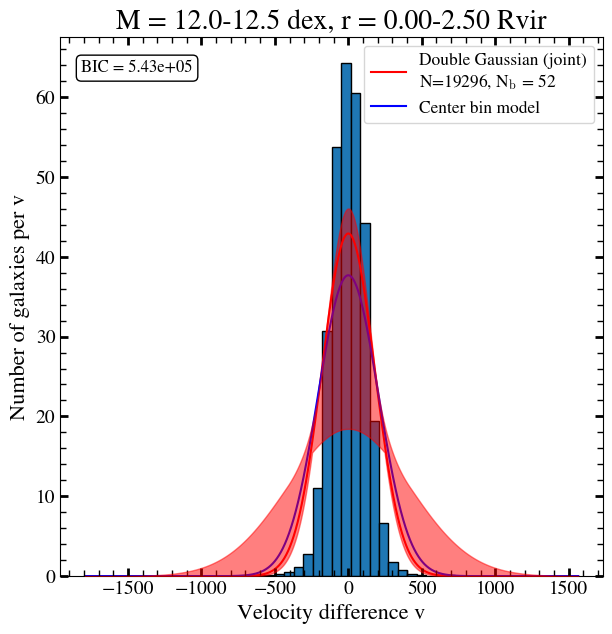

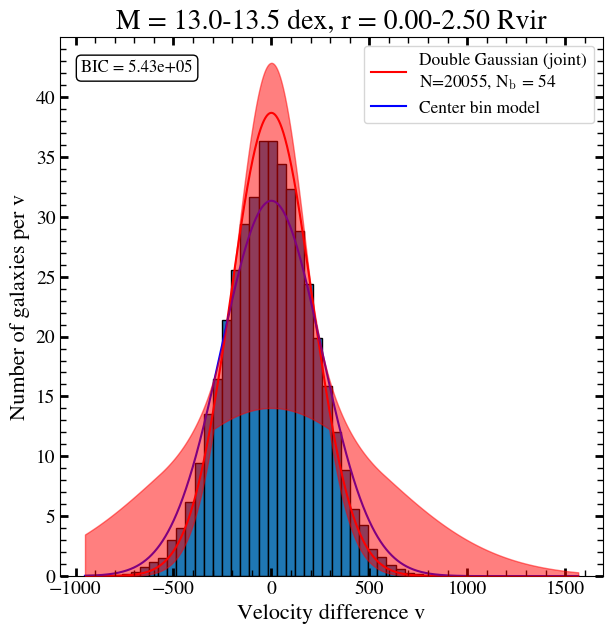

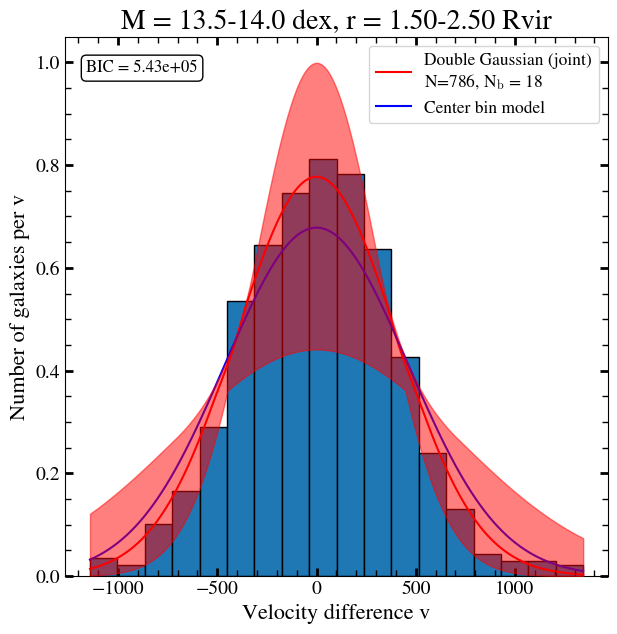

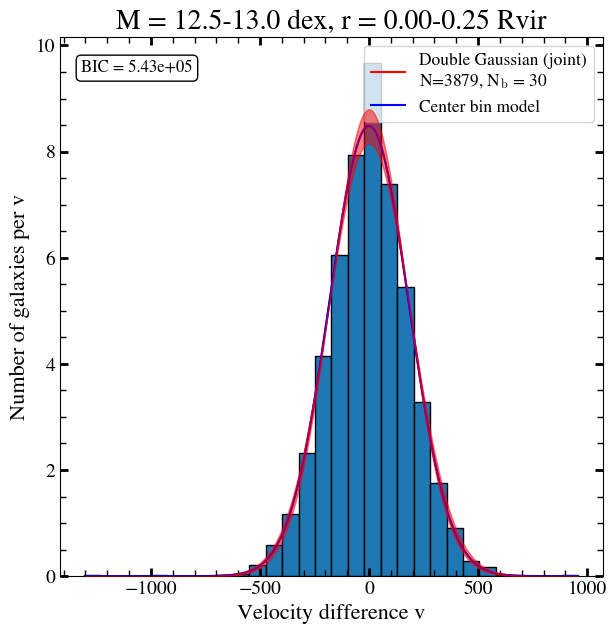

In [73]:
prior_mask = log_prior_vec(DG) == 0

def plot_in_bin(best_params: np.ndarray, function_combi: list, combi_number: int,
                n_params_r: int, n_params_m: list,
                BIC_score: np.float32, mbin: list | tuple, rbin: list | tuple, show: bool = False,
                filepath: str = '/disks/cosmodm/vdvuurst/figures/onehalo_joint/subsampled') -> None:
    
        halo_masses_prior = halo_masses[prior_mask]
        rel_dist_prior = rel_dist[prior_mask]

        # Define the bin
        mbin_mask = ONEHALO._make_mass_mask(halo_masses_prior, *mbin, logmass = True)
        rbin_mask = ONEHALO._make_radial_mask(rel_dist_prior, *rbin)
        bin_mask = np.logical_and(mbin_mask, rbin_mask)

        # Get binned data
        vel_data_in_bin = rel_vels[prior_mask][bin_mask].flatten() # first apply mask to all 3-vectors, then flatten
        min_half_v_sq_in_bin = joint_test.min_half_v_sq_arr[prior_mask][bin_mask]
        masses_in_bin = halo_masses_prior[bin_mask]
        rel_dist_in_bin = rel_dist_prior[bin_mask]

        bins = rice_bins(vel_data_in_bin.size)
        filename = os.path.join(filepath, f'function_combi_{combi_number}')
        mkdir_if_non_existent(filename)
        filename = os.path.join(filename, f'{ONEHALO.str_from_mbin(mbin)}_{ONEHALO.str_from_rbin(rbin)}_fit.png')

        DG_params = joint_test.get_double_gauss_parameters(joint_test.split_parameters(best_params, n_params_m), function_combi,
                                                        n_params_r, masses_in_bin, rel_dist_in_bin)


        # Plotting
        fig, ax = plt.subplots(figsize = (7,7))
        ax.set_xlabel('Velocity difference v', fontsize=16)
        ax.set_ylabel('Number of galaxies per v', fontsize=16)
        ax.tick_params(axis='both', which='major',length=6, width=2,labelsize=14)

        # Bin velocity histogram and plot it
        bin_heights, bin_edges = np.histogram(vel_data_in_bin, bins=bins, density=False)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width= bin_edges[1] - bin_edges[0] 
        bin_widths = np.diff(bin_edges)  # The width of each bin
        number_density = bin_heights / bin_widths  # Normalize by bin width
        hist_area=np.sum(bin_heights)
        ax.bar(bin_centers, number_density, width=bin_width, align='center', edgecolor = 'black')

        # Add BIC score in textbox
        ax.text(0.155, 0.83, f'BIC = {BIC_score:.2e}', transform=plt.gcf().transFigure,
                backgroundcolor='white',zorder=-1,
                bbox = {'boxstyle':'round','facecolor':'white'}, fontsize = 12)


        DAT = np.linspace(np.min(vel_data_in_bin),np.max(vel_data_in_bin), min_half_v_sq_in_bin.size)

        ax_func = lambda x: hist_area * double_gaussian(DAT, *x).flatten()
        all_models = np.apply_along_axis(ax_func, 0, DG_params)
        min_model_at_point = np.min(all_models, axis = 1)
        max_model_at_point = np.max(all_models, axis = 1)

        plot_data = np.median(all_models, axis = 1)

        ax.plot(DAT.flatten(), plot_data.flatten(), '-', label = f"Double Gaussian (joint)\nN={hist_area:.0f}, N" + r'$_\mathrm{b}$' + f" = {bins}",
                color='red', zorder = 1)
        ax.fill_between(DAT.flatten(), min_model_at_point, max_model_at_point, alpha = 0.5, color = 'red', zorder = 10)


        center_bin_mass, center_bin_rad = np.mean(mbin), np.mean(rbin)

        DG_center = joint_test.get_double_gauss_parameters(joint_test.split_parameters(best_params, n_params_m), function_combi,
                                                        n_params_r, center_bin_mass, center_bin_rad)
        
        ax.plot(DAT.flatten(), ax_func(DG_center), label = 'Center bin model', color = 'blue', zorder = 1, lw = 1.5)

        ax.legend(fontsize=12.5, loc="upper right")
        ax.set_title(f'{ONEHALO.str_from_mbin(mbin).replace('_',' = ')} dex, {ONEHALO.str_from_rbin(rbin).replace('_',' = ')} Rvir', fontsize = 20)

        if not show:
                fig.savefig(filename, dpi=200)
                plt.close()
        else:
                plt.show()

DG_good = DG[:, prior_mask]
LGood = double_gaussian_log_likelihood_vec(DG_good, joint_test.min_half_v_sq_arr[prior_mask])
BIC_score = BIC(-1*LGood, DG_good.shape[1], ntot)

plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [2.0, 3.5], [0.00, 0.10], show = True)
plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [2.0, 3.5], [0.00, 0.5], show = True)
plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [2.0, 2.5], [0.00, 2.5], show = True)
plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [3.0, 3.5], [0.00, 2.5], show = True)
plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [3.5, 4.0], [1.5, 2.5], show = True)
plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [2.5, 3.0], [0.00, 0.25], show = True)

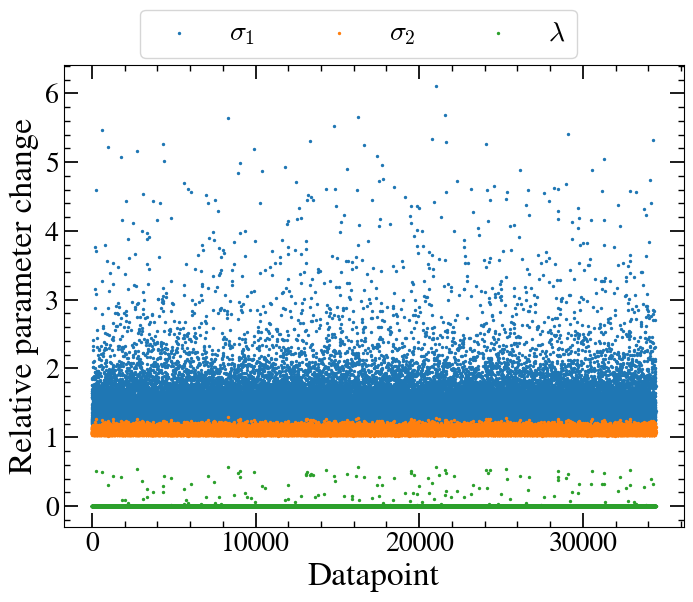

In [74]:
fig, ax = plt.subplots(figsize = (8,6))

s1, s2, lam = DG
s1_change = s1 / 150.
s2_change = s2 / 50.
lam_change = lam / 0.1

xvals = np.arange(s1.shape[0])
ax.scatter(xvals, s1_change, s = 2, label = r'$\sigma_1$')
ax.scatter(xvals, s2_change, s = 2, label = r'$\sigma_2$')
ax.scatter(xvals, lam_change, s = 2, label = r'$\lambda$')
ax.legend(bbox_to_anchor = (0.85, 1.15), ncols = 3)
ax.set(ylabel = 'Relative parameter change', xlabel = 'Datapoint')

plt.show()

## Looking at the goodness of initial conditions

In [75]:
def get_init_DG_from_combi_nr(combi_nr):
    func_combi = all_combis[combi_nr - 1]
    n_params_r, n_params_m, ntot = ONEHALO.param_info(func_combi)
    init_guess, MCMC_scales = np.load(f'/disks/cosmodm/vdvuurst/data/onehalo_joint_initial_conditions/function_combi_{combi_nr}.npy')
    
    split_params = joint_test.split_parameters(init_guess, n_params_m)
    DG = joint_test.get_double_gauss_parameters(split_params, func_combi, n_params_r)

    return DG

for cnr in best_combi_nrs: # sorted on bic score:
    DG_init_i = get_init_DG_from_combi_nr(cnr)
    print(cnr, DG_init_i[2].nonzero())

4427 (array([], dtype=int64),)
6236 (array([], dtype=int64),)
5259 (array([], dtype=int64),)
5277 (array([], dtype=int64),)
4556 (array([], dtype=int64),)
6397 (array([], dtype=int64),)
2434 (array([], dtype=int64),)
5312 (array([], dtype=int64),)
6332 (array([], dtype=int64),)
6185 (array([], dtype=int64),)
7514 (array([], dtype=int64),)
7556 (array([], dtype=int64),)
2559 (array([], dtype=int64),)
6266 (array([], dtype=int64),)
7630 (array([], dtype=int64),)
5192 (array([], dtype=int64),)
5893 (array([], dtype=int64),)
2063 (array([], dtype=int64),)
9168 (array([], dtype=int64),)
1529 (array([], dtype=int64),)
7209 (array([], dtype=int64),)
6864 (array([], dtype=int64),)
3074 (array([], dtype=int64),)
7100 (array([], dtype=int64),)
7271 (array([], dtype=int64),)
1185 (array([], dtype=int64),)
3557 (array([], dtype=int64),)
3386 (array([], dtype=int64),)
5676 (array([], dtype=int64),)
3562 (array([], dtype=int64),)
5052 (array([], dtype=int64),)
1268 (array([], dtype=int64),)
7042 (ar

In [76]:
init_guess, _ = np.load(f'/disks/cosmodm/vdvuurst/data/onehalo_joint_initial_conditions/function_combi_{combi_nr}.npy')

simple = _init_conditions(test_func_combi_names)

# simplistic initial conditions
split_params = joint_test.split_parameters(np.array(simple), n_params_m)
DGsimple = joint_test.get_double_gauss_parameters(split_params, test_func_combi, n_params_r)

# after BFGS minimization initial conditions
split_params2 = joint_test.split_parameters(init_guess, n_params_m)
DGsimple2 = joint_test.get_double_gauss_parameters(split_params2, test_func_combi, n_params_r)

#comparison
Lsimple = double_gaussian_log_likelihood_vec(DGsimple, rel_vels)
Lsimple2 = double_gaussian_log_likelihood_vec(DGsimple2, rel_vels)
print(f'{Lsimple > Lsimple2 = }')
Lsimple, Lsimple2

Lsimple > Lsimple2 = np.False_


(np.float64(201856.4438339624), np.float64(204253.69942158848))